En esta primera fase configuramos el entorno de análisis y procedemos a la ingesta de las predicciones crudas y de las métricas de entrenamiento previas. 

También definimos las constantes operativas necesarias para el simulador de rentabilidad. Cabe destacar que la tarifa de 12,48 €/h hace referencia exclusiva al coste empresarial ponderado del técnico especialista de Back Office (Nivel 2). Bajo el escenario operativo analizado, el tiempo invertido por el Front Office en la creación inicial del ticket se asume como un coste hundido, recayendo el potencial de ahorro (ROI) únicamente en la mitigación de los re-escalados en el Nivel 2.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.1)

ruta_predicciones = "../results/predicciones_holdout_roberta.csv"
ruta_kfold_nativo = "../metrics/resultados_kfold_nativo.csv"
ruta_kfold_roberta = "../metrics/resultados_kfold_roberta.csv"

df_predicciones = pd.read_csv(ruta_predicciones)
df_kfold_nativo = pd.read_csv(ruta_kfold_nativo)
df_kfold_roberta = pd.read_csv(ruta_kfold_roberta)

volumen_mensual_tickets = 14500
aht_correccion_bo_segundos = 120
coste_hora_bo_euros = 12.48
tasa_error_fo_base = 0.15
tasa_error_fo_estres = 0.25

print(f"Predicciones cargadas: {df_predicciones.shape[0]} registros.")

Predicciones cargadas: 5930 registros.


En esta sección justificamos empíricamente el salto arquitectónico hacia modelos de Deep Learning frente a la línea base tradicional (TF-IDF + Random Forest). 

Realizamos la comparativa utilizando los resultados de la validación cruzada (K-Fold) de ambos algoritmos. Esta restricción de simetría estadística es crítica: nos permite aislar la varianza interna de cada modelo frente a rotaciones del conjunto de datos. El objetivo es evidenciar que el incremento del F1-Macro y la drástica reducción del Log-Loss del Transformer son estructurales y estables, descartando que el rendimiento se deba a un sobreajuste estocástico sobre un pliegue de datos concreto.

C:\Users\andre\AppData\Local\Temp\ipykernel_21572\21395379.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\andre\AppData\Local\Temp\ipykernel_21572\21395379.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


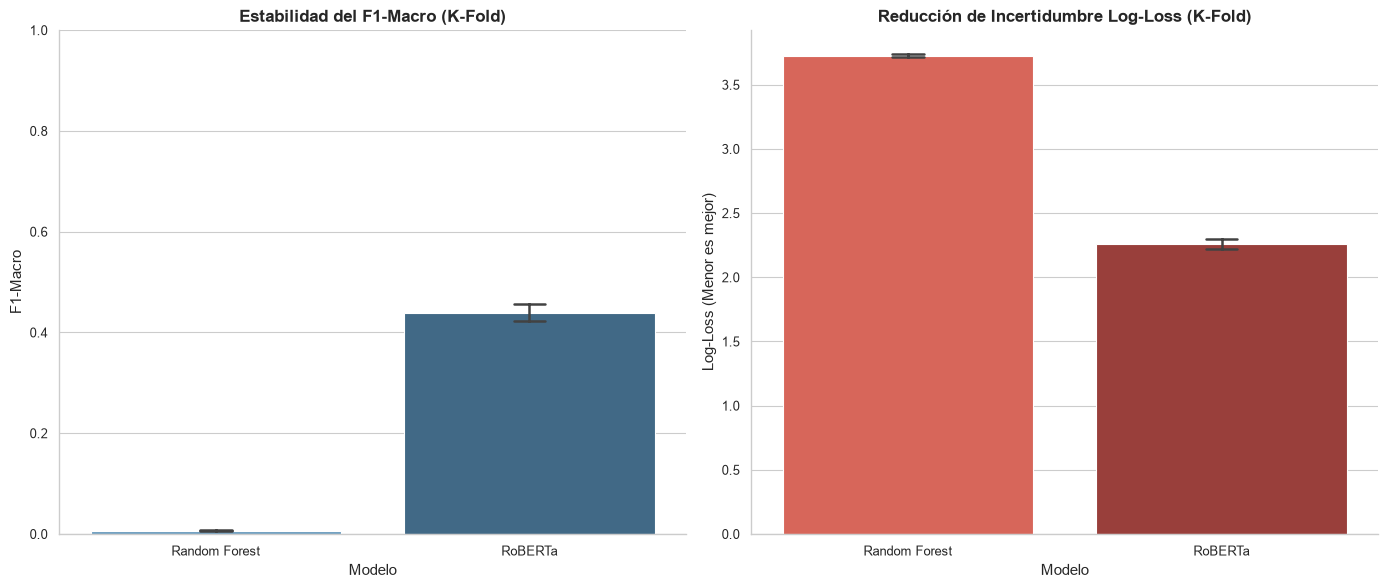

Gráfico exportado exitosamente en: ../images/07_comparativa_kfold_baseline_roberta.png


In [5]:
df_nativo_temp = df_kfold_nativo[['f1_macro', 'log_loss']].copy()
df_nativo_temp['Modelo'] = 'Random Forest'

df_roberta_temp = df_kfold_roberta[['f1_macro', 'log_loss']].copy()
df_roberta_temp['Modelo'] = 'RoBERTa'

df_comparativa = pd.concat([df_nativo_temp, df_roberta_temp], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_comparativa, 
    x='Modelo', 
    y='f1_macro', 
    ax=axes[0], 
    palette="Blues_d", 
    errorbar='sd', 
    capsize=0.1
)
axes[0].set_title('Estabilidad del F1-Macro (K-Fold)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1-Macro')
axes[0].set_ylim(0, 1)

sns.barplot(
    data=df_comparativa, 
    x='Modelo', 
    y='log_loss', 
    ax=axes[1], 
    palette="Reds_d", 
    errorbar='sd', 
    capsize=0.1
)
axes[1].set_title('Reducción de Incertidumbre Log-Loss (K-Fold)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log-Loss (Menor es mejor)')

sns.despine()
plt.tight_layout()

ruta_imagen_celda2 = "../images/07_comparativa_kfold_baseline_roberta.png"
plt.savefig(ruta_imagen_celda2, dpi=300, bbox_inches='tight')

plt.show()

print(f"Gráfico exportado exitosamente en: {ruta_imagen_celda2}")

Esta sección ejecuta una auditoría de fricción taxonómica. Evaluar la exactitud global del modelo es insuficiente para autorizar un pase a producción; es obligatorio identificar los cuellos de botella semánticos donde la red neuronal confunde sistemáticamente categorías afines.

Para mitigar el ruido visual de una matriz de confusión completa, aislamos matemáticamente los verdaderos positivos (la diagonal) y extraemos las 10 colisiones más frecuentes (falsos positivos/negativos). El mapa de calor resultante se centra exclusivamente en este subconjunto de clases, exponiendo de forma transparente las vulnerabilidades de clasificación del modelo.

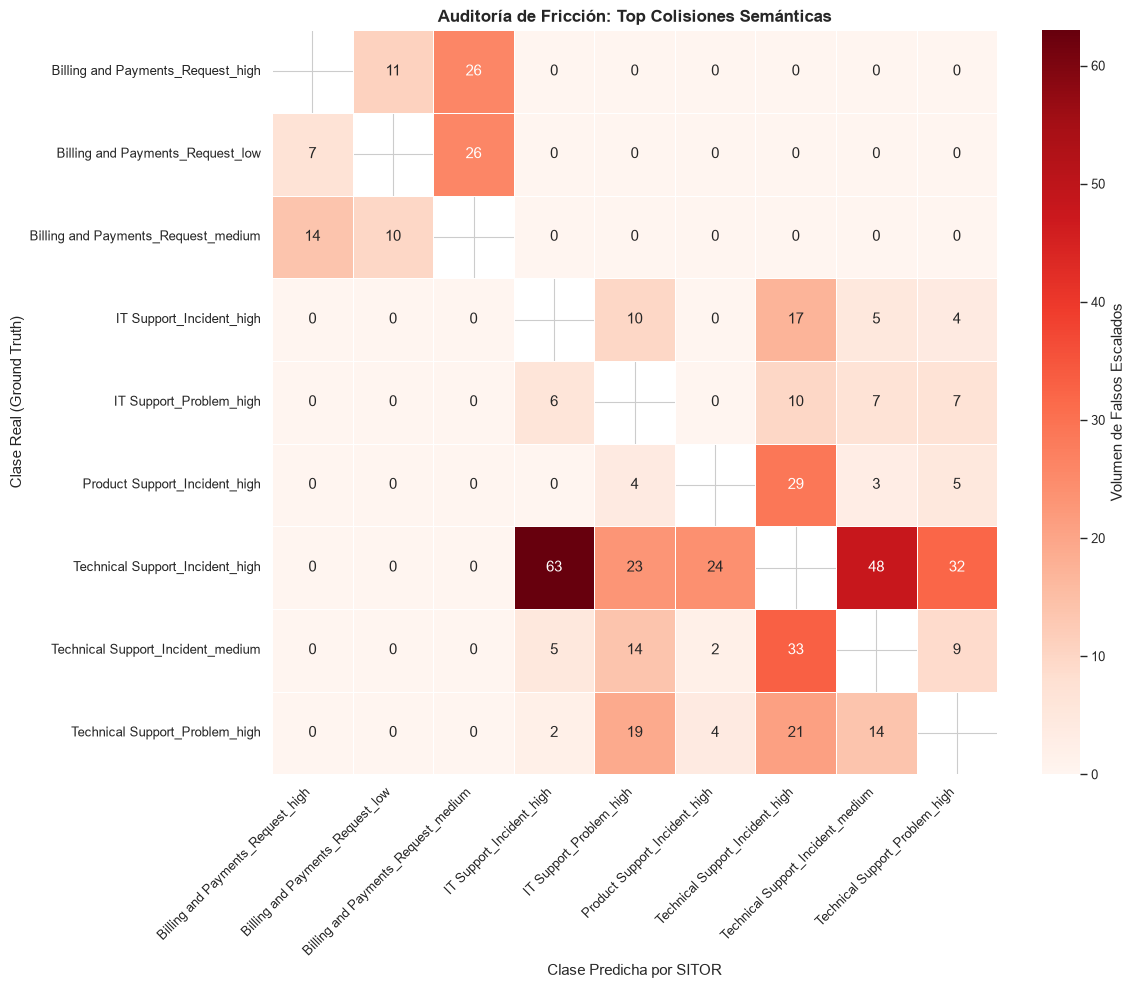

Matriz de colisiones exportada correctamente en: ../images/07_matriz_friccion_top10.png


In [7]:
matriz_completa = pd.crosstab(df_predicciones['target_tripleta_real'], df_predicciones['prediccion_roberta'])

matriz_errores = matriz_completa.copy()
for clase in matriz_errores.columns:
    if clase in matriz_errores.index:
        matriz_errores.loc[clase, clase] = 0

pares_error = matriz_errores.unstack().reset_index()
pares_error.columns = ['Prediccion', 'Real', 'Frecuencia']
pares_error = pares_error[pares_error['Real'] != pares_error['Prediccion']]

top_10_errores = pares_error.sort_values(by='Frecuencia', ascending=False).head(10)

clases_involucradas = pd.concat([top_10_errores['Real'], top_10_errores['Prediccion']]).unique()
clases_comunes = sorted(clases_involucradas)

matriz_top_errores = matriz_completa.reindex(index=clases_comunes, columns=clases_comunes, fill_value=0)

mascara_diagonal = np.eye(len(clases_comunes), dtype=bool)

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_top_errores, 
    annot=True, 
    fmt="d", 
    cmap="Reds", 
    mask=mascara_diagonal,
    cbar_kws={'label': 'Volumen de Falsos Escalados'},
    linewidths=.5
)

plt.title('Auditoría de Fricción: Top Colisiones Semánticas', fontsize=12, fontweight='bold')
plt.xlabel('Clase Predicha por SITOR')
plt.ylabel('Clase Real (Ground Truth)')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

ruta_imagen_celda3 = "../images/07_matriz_friccion_top10.png"
plt.savefig(ruta_imagen_celda3, dpi=300, bbox_inches='tight')
plt.show()

print(f"Matriz de colisiones exportada correctamente en: {ruta_imagen_celda3}")

Esta sección cumple un propósito defensivo de cara a la Dirección de Operaciones. Evaluamos la distribución de la certidumbre matemática (vector de confianza) de todas las inferencias emitidas por el modelo en el conjunto de prueba.

A diferencia de un árbol de decisión rígido, la red neuronal evalúa la probabilidad diferencial de su propia decisión. Proyectamos la densidad del flujo mediante un estimador de núcleo (KDE) y trazamos una frontera de decisión teórica en el umbral del 0.60. Esta visualización evidencia que la arquitectura aplica un principio de precaución: la masa de tickets que caen en el área gris será ignorada por el orquestador (regla de pasividad), mientras que solo la concentración en el área verde activará la reasignación automatizada.

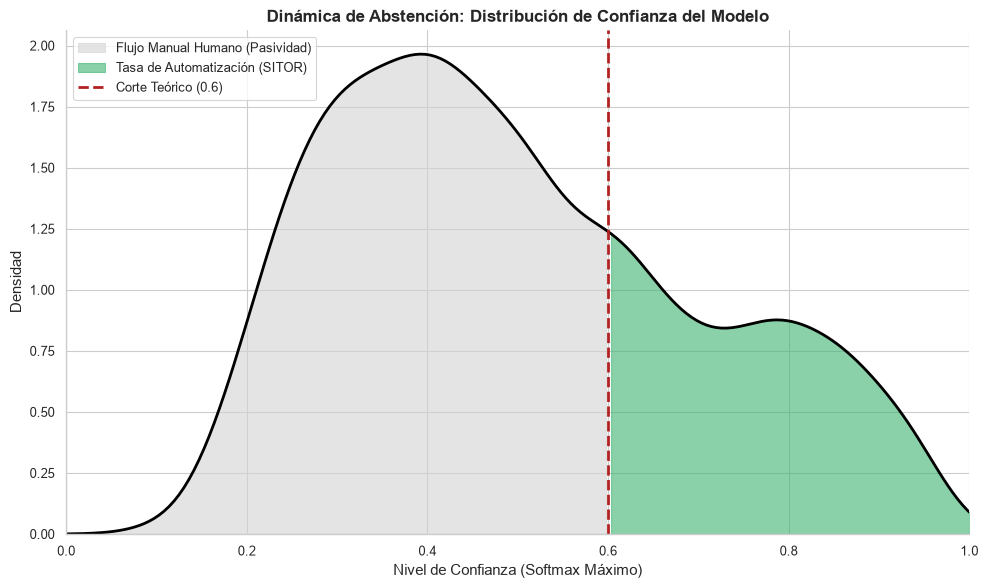

Curva de densidad de confianza exportada en: ../images/07_distribucion_confianza_kde.png


In [8]:
umbral_referencia = 0.60

plt.figure(figsize=(10, 6))
ax = sns.kdeplot(data=df_predicciones, x='confianza', color="black", lw=2)

x_kde, y_kde = ax.lines[0].get_data()

ax.fill_between(
    x_kde, 0, y_kde, 
    where=(x_kde < umbral_referencia), 
    color='lightgray', 
    alpha=0.6,
    label='Flujo Manual Humano (Pasividad)'
)

ax.fill_between(
    x_kde, 0, y_kde, 
    where=(x_kde >= umbral_referencia), 
    color='mediumseagreen', 
    alpha=0.6,
    label='Tasa de Automatización (SITOR)'
)

plt.axvline(x=umbral_referencia, color='firebrick', linestyle='--', lw=2, label=f'Corte Teórico ({umbral_referencia})')

plt.title('Dinámica de Abstención: Distribución de Confianza del Modelo', fontsize=12, fontweight='bold')
plt.xlabel('Nivel de Confianza (Softmax Máximo)')
plt.ylabel('Densidad')
plt.xlim(0, 1.0)
plt.legend(loc='upper left')

sns.despine()
plt.tight_layout()

ruta_imagen_celda4 = "../images/07_distribucion_confianza_kde.png"
plt.savefig(ruta_imagen_celda4, dpi=300, bbox_inches='tight')
plt.show()

print(f"Curva de densidad de confianza exportada en: {ruta_imagen_celda4}")

En este bloque abordamos el motor financiero del orquestador mediante un cálculo de optimización vectorial pura. Evitamos fijar un umbral de decisión estático; en su lugar, simulamos el impacto en el Back Office iterando los niveles de certeza algorítmica desde 0.50 hasta 0.99.

La lógica subyacente es que, a mayor exigencia de confianza, el modelo retiene un menor porcentaje del volumen total (caída de la tasa de automatización), pero la exactitud sobre ese subconjunto específico es significativamente mayor. El modelo matemático cruza las horas de técnico recuperadas al prevenir errores del Front Office contra las horas perdidas por los nuevos errores introducidos por los falsos positivos de la IA. Acumulamos el estado de todas las iteraciones en vectores de memoria para localizar, de forma algorítmica, el punto exacto de *Break-Even* que maximiza el Retorno de Inversión.


--- AUDITORÍA DE RENDIMIENTO (ESCENARIO BASE: 15% ERROR FO) ---
Umbral de Confianza Óptimo: 0.80
Ahorro Neto Proyectado:     63.83 €/mes
Tasa de Automatización:     11.2 %
Volumen Intervenido:        1,626 tickets/mes
Precisión Condicionada IA:  94.44 %

--- AUDITORÍA DE RENDIMIENTO (ESCENARIO ESTRÉS: 25% ERROR FO) ---
Umbral de Confianza Óptimo: 0.75
Ahorro Neto Proyectado:     153.85 €/mes
Tasa de Automatización:     15.9 %
Volumen Intervenido:        2,301 tickets/mes
Precisión Condicionada IA:  91.07 %


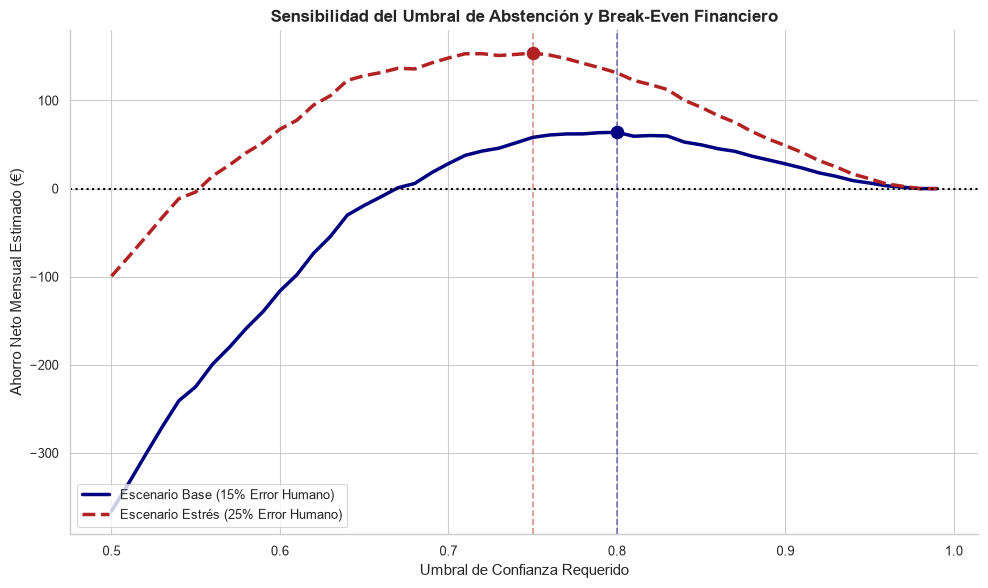

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

umbrales = np.arange(0.50, 1.00, 0.01)

resultados_base = []
resultados_estres = []
tasas_automatizacion = []
precisiones = []
volumenes_intervenidos = []

total_tickets_holdout = len(df_predicciones)

for u in umbrales:
    df_filtro = df_predicciones[df_predicciones['confianza'] >= u]
    
    if len(df_filtro) == 0:
        resultados_base.append(0)
        resultados_estres.append(0)
        tasas_automatizacion.append(0)
        precisiones.append(0)
        volumenes_intervenidos.append(0)
        continue
        
    tasa = len(df_filtro) / total_tickets_holdout
    precision = (df_filtro['target_tripleta_real'] == df_filtro['prediccion_roberta']).mean()
    volumen = volumen_mensual_tickets * tasa
    
    errores_sitor = volumen * (1.0 - precision)
    
    errores_humanos_base = volumen * tasa_error_fo_base
    ahorro_neto_tickets_base = errores_humanos_base - errores_sitor
    ahorro_euros_base = (ahorro_neto_tickets_base * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros
    
    errores_humanos_estres = volumen * tasa_error_fo_estres
    ahorro_neto_tickets_estres = errores_humanos_estres - errores_sitor
    ahorro_euros_estres = (ahorro_neto_tickets_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros
    
    resultados_base.append(ahorro_euros_base)
    resultados_estres.append(ahorro_euros_estres)
    tasas_automatizacion.append(tasa)
    precisiones.append(precision)
    volumenes_intervenidos.append(volumen)

resultados_base = np.array(resultados_base)
resultados_estres = np.array(resultados_estres)
tasas_automatizacion = np.array(tasas_automatizacion)
precisiones = np.array(precisiones)
volumenes_intervenidos = np.array(volumenes_intervenidos)

idx_base = np.argmax(resultados_base)
umbral_optimo_base = umbrales[idx_base]
max_ahorro_base = resultados_base[idx_base]
tasa_optima_base = tasas_automatizacion[idx_base]
volumen_optimo_base = volumenes_intervenidos[idx_base]
precision_optima_base = precisiones[idx_base]

idx_estres = np.argmax(resultados_estres)
umbral_optimo_estres = umbrales[idx_estres]
max_ahorro_estres = resultados_estres[idx_estres]
tasa_optima_estres = tasas_automatizacion[idx_estres]
volumen_optimo_estres = volumenes_intervenidos[idx_estres]
precision_optima_estres = precisiones[idx_estres]

print("--- AUDITORÍA DE RENDIMIENTO (ESCENARIO BASE: 15% ERROR FO) ---")
print(f"Umbral de Confianza Óptimo: {umbral_optimo_base:.2f}")
print(f"Ahorro Neto Proyectado:     {max_ahorro_base:,.2f} €/mes")
print(f"Tasa de Automatización:     {tasa_optima_base * 100:.1f} %")
print(f"Volumen Intervenido:        {volumen_optimo_base:,.0f} tickets/mes")
print(f"Precisión Condicionada IA:  {precision_optima_base * 100:.2f} %\n")

print("--- AUDITORÍA DE RENDIMIENTO (ESCENARIO ESTRÉS: 25% ERROR FO) ---")
print(f"Umbral de Confianza Óptimo: {umbral_optimo_estres:.2f}")
print(f"Ahorro Neto Proyectado:     {max_ahorro_estres:,.2f} €/mes")
print(f"Tasa de Automatización:     {tasa_optima_estres * 100:.1f} %")
print(f"Volumen Intervenido:        {volumen_optimo_estres:,.0f} tickets/mes")
print(f"Precisión Condicionada IA:  {precision_optima_estres * 100:.2f} %")

plt.figure(figsize=(10, 6))

plt.plot(umbrales, resultados_base, label='Escenario Base (15% Error Humano)', color='navy', lw=2.5)
plt.plot(umbrales, resultados_estres, label='Escenario Estrés (25% Error Humano)', color='firebrick', lw=2.5, linestyle='--')
plt.axhline(0, color='black', lw=1.5, linestyle=':')

plt.axvline(umbral_optimo_base, color='navy', linestyle='--', alpha=0.5)
plt.scatter(umbral_optimo_base, max_ahorro_base, color='navy', s=80, zorder=5)

plt.axvline(umbral_optimo_estres, color='firebrick', linestyle='--', alpha=0.5)
plt.scatter(umbral_optimo_estres, max_ahorro_estres, color='firebrick', s=80, zorder=5)

plt.title('Sensibilidad del Umbral de Abstención y Break-Even Financiero', fontsize=12, fontweight='bold')
plt.xlabel('Umbral de Confianza Requerido')
plt.ylabel('Ahorro Neto Mensual Estimado (€)')
plt.legend(loc='lower left')

sns.despine()
plt.tight_layout()

ruta_imagen_celda5 = "../images/07_curva_sensibilidad_roi.png"
plt.savefig(ruta_imagen_celda5, dpi=300, bbox_inches='tight')
plt.show()

En esta sección materializamos la viabilidad financiera del orquestador mediante un gráfico de cascada. Para proyectar el verdadero valor operativo de la red neuronal, sometemos el modelo a un escenario de alto estrés (25 % de error humano en Front Office), emulando picos de estacionalidad, campañas agresivas o la entrada masiva de perfiles junior al Nivel 1.

Consolidamos las métricas extraídas en el umbral óptimo de estrés del bloque anterior para desglosar el flujo de caja del Back Office. Trazamos el coste base proyectado bajo este caos humano, substraemos el ahorro bruto generado por las correcciones acertadas de SITOR, y penalizamos el rendimiento sumando el daño colateral (falsos positivos). El coste operativo optimizado demuestra la resiliencia financiera de la IA en los entornos más hostiles.

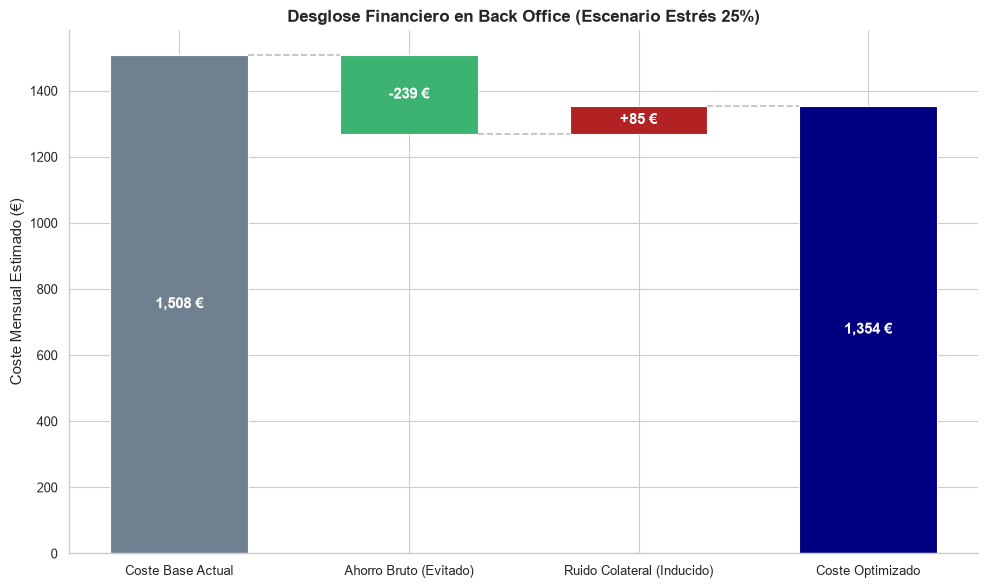

Gráfico Waterfall exportado en: ../images/07_waterfall_financiero_estres.png


In [11]:
coste_base_mensual = (volumen_mensual_tickets * tasa_error_fo_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

ahorro_bruto = (volumen_optimo_estres * tasa_error_fo_estres * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

coste_inducido = (volumen_optimo_estres * (1.0 - precision_optima_estres) * aht_correccion_bo_segundos / 3600) * coste_hora_bo_euros

coste_optimizado = coste_base_mensual - ahorro_bruto + coste_inducido

etiquetas = ['Coste Base Actual', 'Ahorro Bruto (Evitado)', 'Ruido Colateral (Inducido)', 'Coste Optimizado']
valores = [coste_base_mensual, ahorro_bruto, coste_inducido, coste_optimizado]

bases = [
    0, 
    coste_base_mensual - ahorro_bruto, 
    coste_base_mensual - ahorro_bruto, 
    0
]

colores = ['slategray', 'mediumseagreen', 'firebrick', 'navy']

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(etiquetas, valores, bottom=bases, color=colores, width=0.6)

for i, barra in enumerate(barras):
    altura = barra.get_height()
    base = barra.get_y()
    signo = "-" if i == 1 else ("+" if i == 2 else "")
    ax.text(
        barra.get_x() + barra.get_width() / 2, 
        base + altura / 2, 
        f'{signo}{altura:,.0f} €', 
        ha='center', va='center', color='white', fontweight='bold'
    )

ax.plot([0.3, 0.7], [coste_base_mensual, coste_base_mensual], color='gray', linestyle='--', alpha=0.5)
ax.plot([1.3, 1.7], [coste_base_mensual - ahorro_bruto, coste_base_mensual - ahorro_bruto], color='gray', linestyle='--', alpha=0.5)
ax.plot([2.3, 2.7], [coste_optimizado, coste_optimizado], color='gray', linestyle='--', alpha=0.5)

plt.title('Desglose Financiero en Back Office (Escenario Estrés 25%)', fontsize=12, fontweight='bold')
plt.ylabel('Coste Mensual Estimado (€)')
sns.despine()
plt.tight_layout()

ruta_imagen_celda6 = "../images/07_waterfall_financiero_estres.png"
plt.savefig(ruta_imagen_celda6, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico Waterfall exportado en: {ruta_imagen_celda6}")

In [12]:
from IPython.display import display, Markdown

cierre_ejecutivo = f"""
### Conclusiones Estratégicas: El ROI Intangible y la Macro-Eficiencia

El análisis de rentabilidad expuesto en el gráfico de cascada representa de forma estricta el "suelo" financiero del proyecto. Los **{max_ahorro_estres:,.2f} € netos recuperados al mes** se han modelado tomando en cuenta únicamente el coste directo (*payroll*) correspondiente al tiempo que el técnico de Nivel 2 pierde reasignando tipologías. 

Sin embargo, el verdadero impacto de negocio de la red neuronal reside en la intercepción automatizada de **{volumen_optimo_estres:,.0f} falsos escalados mensuales** bajo el escenario de estrés, neutralizándolas antes de que impacten en la operativa técnica. Esto blinda la macro-eficiencia del BPO en cuatro vectores:

1. **Amortización de la Rotación Temprana (Attrition):** El orquestador opera como una sistema de validación automática. Si la tasa de error del Front Office se dispara al 25 % por la entrada masiva de agentes junior durante campañas estacionales, SITOR absorbe el golpe. Esto permite operaciones agresivas de contratación sin que el cliente perciba la inexperiencia de la primera línea.
2. **Desestrangulamiento del Backlog (Nivel 2):** Al blindar al *Back Office* del ruido de estos miles de falsos escalados, el equipo absorbe mayor carga resolutiva cualificada. Retrasar o anular la necesidad de contratar un solo *FTE* adicional en L2 amortiza instantáneamente la arquitectura de Deep Learning.
3. **Protección del SLA y Prevención de Penalizaciones:** En la dinámica de *Ping-Pong*, un ticket rebotado sufre tiempos de espera redundantes. SITOR recorta drásticamente la latencia (*Time-to-Resolve*), mitigando el riesgo de multas por rupturas de los *Service Level Agreements*.
4. **Contención del NPS y Riesgo de Churn:** La eliminación de la fricción interna acelera la entrega de valor al cliente. Esta caída en los tiempos de espera protege directamente el *Net Promoter Score*.
"""

display(Markdown(cierre_ejecutivo))


### Conclusiones Estratégicas: El ROI Intangible y la Macro-Eficiencia

El análisis de rentabilidad expuesto en el gráfico de cascada representa de forma estricta el "suelo" financiero del proyecto. Los **153.85 € netos recuperados al mes** se han modelado tomando en cuenta únicamente el coste directo (*payroll*) correspondiente al tiempo que el técnico de Nivel 2 pierde reasignando tipologías. 

Sin embargo, el verdadero impacto de negocio de la red neuronal reside en la intercepción automatizada de **2,301 falsos escalados mensuales** bajo el escenario de estrés, neutralizándolas antes de que impacten en la operativa técnica. Esto blinda la macro-eficiencia del BPO en cuatro vectores:

1. **Amortización de la Rotación Temprana (Attrition):** El orquestador opera como una sistema de validación automática. Si la tasa de error del Front Office se dispara al 25 % por la entrada masiva de agentes junior durante campañas estacionales, SITOR absorbe el golpe. Esto permite operaciones agresivas de contratación sin que el cliente perciba la inexperiencia de la primera línea.
2. **Desestrangulamiento del Backlog (Nivel 2):** Al blindar al *Back Office* del ruido de estos miles de falsos escalados, el equipo absorbe mayor carga resolutiva cualificada. Retrasar o anular la necesidad de contratar un solo *FTE* adicional en L2 amortiza instantáneamente la arquitectura de Deep Learning.
3. **Protección del SLA y Prevención de Penalizaciones:** En la dinámica de *Ping-Pong*, un ticket rebotado sufre tiempos de espera redundantes. SITOR recorta drásticamente la latencia (*Time-to-Resolve*), mitigando el riesgo de multas por rupturas de los *Service Level Agreements*.
4. **Contención del NPS y Riesgo de Churn:** La eliminación de la fricción interna acelera la entrega de valor al cliente. Esta caída en los tiempos de espera protege directamente el *Net Promoter Score*.
